In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import scipy.stats as sp_stats
from tqdm import tqdm
from scipy import stats
import os

In [ ]:
# Load data
returns = pd.read_stata("/content/drive/MyDrive/Empirical Methods for Finance Assignment/Assignment 1/daily_returns_new.dta")
events = pd.read_csv("/content/drive/MyDrive/Empirical Methods for Finance Assignment/Assignment 1/dividend_events.csv")

# Rename columns for clarity
returns = returns.rename(columns={
    "DlyCalDt": "date",
    "DlyRet": "total_return",
    "DlyCap": "marketcap",
    "DlyVol": "volume"
})

events = events.rename(columns={
    "date": "event_date",
    "dividend": "new_dividend",
    "previous_dividend": "old_dividend"
})

# Convert dates and identifiers
returns["date"] = pd.to_datetime(returns["date"])
events["event_date"] = pd.to_datetime(events["event_date"], format="%d%b%Y", errors="coerce")
returns['PERMNO'] = returns['PERMNO'].astype(int)
events['PERMNO'] = events['PERMNO'].astype(int)

In [ ]:
# Compute market return
def get_market_return(returns):
  return returns.groupby("date")["total_return"].mean().rename("market_return").reset_index()

# Estimate normal returns using the market model
def estimate_normal_return(df, market, start=-250, end=-30):
  df = df.merge(market, on="date", how="left")
  estimates = []

  for permno, sub in df.groupby("PERMNO"):
    sub = sub[(sub["days_from_event"] >= start) & (sub["days_from_event"] <= end)]
    if len(sub) < 30:
      continue
    X = np.vstack([np.ones(len(sub)), sub["market_return"]]).T
    y = sub["total_return"].values
    beta = np.linalg.lstsq(X, y, rcond=None)[0]
    estimates.append((permno, beta[0], beta[1]))

  return pd.DataFrame(estimates, columns=["PERMNO", "alpha", "beta"])

# Calculate abnormal returns inside the event window
def calculate_abnormal_returns(df, market, est_param, event_window=(-5, +5)):
  df = df.merge(market, on="date", how="left")
  df = df.merge(est_param, on="PERMNO", how="left")
  df["expected_return"] = df["alpha"] + df["beta"] * df["market_return"]
  df["abnormal_return"] = df["total_return"] - df["expected_return"]
  return df[(df["days_from_event"] >= event_window[0]) & (df["days_from_event"] <= event_window[1])]

# Daily t-test for abnormal returns
def t_test_daily(all_events):
    stats = (all_events.groupby("days_from_event")["abnormal_return"]
             .agg(["mean", "std", "count"])
             .assign(t=lambda x: x["mean"] / (x["std"] / np.sqrt(x["count"]))))
    return stats

# CAR and t-test for an event window
def t_test_car(all_events, event_window=(0, 5)):
    car_event = (
        all_events[all_events["days_from_event"].between(event_window[0], event_window[1])]
        .groupby("event_id")["abnormal_return"].sum()
    )
    mean = car_event.mean()
    std = car_event.std(ddof=1)
    n = len(car_event)
    t = mean / (std / np.sqrt(n))
    return mean, t, n

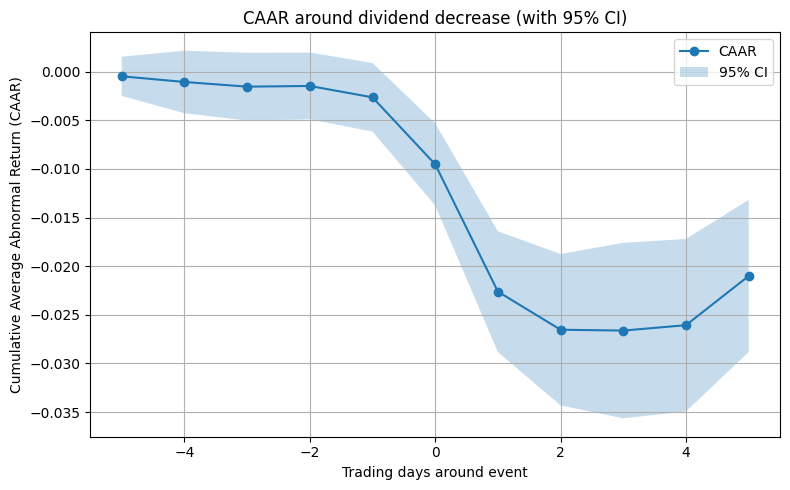


 CAAR values
 days_from_event    CAAR   lower   upper
              -5 -0.0005 -0.0025  0.0015
              -4 -0.0011 -0.0043  0.0021
              -3 -0.0016 -0.0050  0.0019
              -2 -0.0015 -0.0049  0.0020
              -1 -0.0026 -0.0062  0.0009
               0 -0.0095 -0.0138 -0.0053
               1 -0.0226 -0.0288 -0.0164
               2 -0.0265 -0.0343 -0.0188
               3 -0.0266 -0.0356 -0.0176
               4 -0.0261 -0.0349 -0.0172
               5 -0.0210 -0.0288 -0.0132


In [ ]:
# Define windows
EST_WINDOW = (-250, -30)
EVENT_WINDOW = (-5, +5)

returns["date"] = pd.to_datetime(returns["date"])
events = events.dropna(subset=["event_date"])
market = get_market_return(returns)
market["date"] = pd.to_datetime(market["date"])

results = []

# Loop over all events and construct AR/CAR data
for _, ev in events.iterrows():
    firm = returns[returns["PERMNO"] == ev["PERMNO"]].copy()
    if firm.empty:
        continue

    firm["days_from_event"] = (firm["date"] - ev["event_date"]).dt.days

    est = estimate_normal_return(firm, market, start=EST_WINDOW[0], end=EST_WINDOW[1])
    if est.empty:
        continue

    ar = calculate_abnormal_returns(firm, market, est, event_window=EVENT_WINDOW)
    if ar.empty:
        continue

    ar["event_date"] = ev["event_date"]
    ar["event_id"] = f"{int(ev['PERMNO'])}_{ev['event_date'].date()}"
    results.append(ar)

# If events exists, compute CAAR + confidence intervals
if results:
    all_events = pd.concat(results, ignore_index=True)
    all_events = all_events.sort_values(["event_id", "days_from_event"])
    all_events["CAR"] = all_events.groupby("event_id", observed=True)["abnormal_return"].cumsum()


    caar_ci = (
        all_events.groupby("days_from_event", observed=True)["CAR"]
                  .agg(CAAR="mean", std="std", count="count")
                  .reset_index()
                  .sort_values("days_from_event")
    )

    caar_ci["se"] = caar_ci["std"] / np.sqrt(caar_ci["count"])
    caar_ci["upper"] = caar_ci["CAAR"] + 1.96 * caar_ci["se"]
    caar_ci["lower"] = caar_ci["CAAR"] - 1.96 * caar_ci["se"]

    plt.figure(figsize=(8, 5))
    plt.plot(caar_ci["days_from_event"], caar_ci["CAAR"], marker="o", label="CAAR")
    plt.fill_between(caar_ci["days_from_event"], caar_ci["lower"], caar_ci["upper"], alpha=0.25, label="95% CI")
    plt.title("CAAR around dividend decrease (with 95% CI)")
    plt.xlabel("Trading days around event")
    plt.ylabel("Cumulative Average Abnormal Return (CAAR)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("\n CAAR values")
    print(caar_ci[["days_from_event", "CAAR", "lower", "upper"]]
          .round(4)
          .to_string(index=False))
else:
    print("No events found")



In [ ]:
# Daily abnormal return t-tests
stats = t_test_daily(all_events)
print(stats.head())


                     mean       std  count         t
days_from_event                                     
-5              -0.000489  0.032629   1004 -0.475090
-4              -0.000913  0.038424    817 -0.679086
-3              -0.000230  0.036535    843 -0.183128
-2              -0.001037  0.039653   1000 -0.827323
-1              -0.001405  0.041260   1348 -1.250181


In [ ]:
# CAR t-test for default window (0, 5)
mean, tstat, n = t_test_car(all_events)
print(f"Mean CAR: {mean:.4f}, t = {tstat:.2f}, n = {n}")

Mean CAR: -0.0226, t = -8.06, n = 1662


In [ ]:
# Summary table for multiple event windows
windows = [(-1, 1), (-5, 5), (-10, 10)]
rows = []

for w in windows:
    mean, tstat, n = t_test_car(all_events, event_window=w)

    p_value = 2 * (1 - sp_stats.t.cdf(abs(tstat), df=n-1))
    significance = (
        "***" if p_value < 0.01 else
        "**" if p_value < 0.05 else
        "*" if p_value < 0.10 else ""
    )
    rows.append({
        "Window": f"[{w[0]}, {w[1]}]",
        "Mean CAAR": round(mean, 4),
        "t-stat": round(tstat, 2),
        "p-value": round(p_value, 4),
        "Significance": significance,
        "N": n
    })

summary_table = pd.DataFrame(rows)
print(summary_table.to_string(index=False))



=== Final CAAR Summary Table ===
   Window  Mean CAAR  t-stat  p-value Significance    N
  [-1, 1]    -0.0190   -7.70      0.0          *** 1662
  [-5, 5]    -0.0252   -7.87      0.0          *** 1662
[-10, 10]    -0.0252   -7.87      0.0          *** 1662
